# Plot snapshots of ice bridge in Satellite data for supplement

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from pyproj import Proj, Transformer
import glob
import os

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:43063")
client

<Client: 'tcp://127.0.0.1:43063' processes=8 threads=32, memory=123.95 GiB>

In [3]:
ds = xr.open_dataset('/home/jpluser/efs-mount-point/mzahn/sic_nsidc_cdr/sic_psn25_20161026_F17_v05r00.nc')

In [4]:
# Extract x and y
x = ds['x'].values
y = ds['y'].values
X, Y = np.meshgrid(x, y)

# Set up projection: NSIDC Polar Stereographic North (EPSG:3411 equivalent)
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# Transform x/y to lon/lat
lon2d, lat2d = transformer.transform(X, Y)

# Add lat/lon as DataArrays to the dataset
ds = ds.assign_coords({
    "lat": (("y", "x"), lat2d),
    "lon": (("y", "x"), lon2d)
})

# Confirm structure
ds

<xarray.Dataset> Size: 4MB
Dimensions:                               (time: 1, y: 448, x: 304)
Coordinates:
  * x                                     (x) float64 2kB -3.838e+06 ... 3.73...
  * y                                     (y) float64 4kB 5.838e+06 ... -5.33...
  * time                                  (time) datetime64[ns] 8B 2016-10-26
    lat                                   (y, x) float64 1MB 31.1 31.2 ... 34.47
    lon                                   (y, x) float64 1MB 168.3 ... -9.999
Data variables:
    crs                                   int32 4B ...
    cdr_seaice_conc_interp_spatial_flag   (time, y, x) uint8 136kB ...
    cdr_seaice_conc_qa_flag               (time, y, x) uint8 136kB ...
    cdr_seaice_conc_interp_temporal_flag  (time, y, x) uint8 136kB ...
    cdr_seaice_conc                       (time, y, x) float64 1MB ...
    cdr_seaice_conc_stdev                 (time, y, x) float32 545kB ...
Attributes: (12/46)
    Conventions:               CF-1.11, ACDD-1.3
    date_created:              2024-11-12T05:38:14Z
    time_coverage_start:       2016-10-26T00:00:00Z
    time_coverage_end:         2016-10-26T23:59:59Z
    time_coverage_duration:    P1D
    time_coverage_resolution:  P1D
    ...                        ...
    geospatial_lat_min:        30.980564
    geospatial_lat_max:        90.0
    geospatial_lon_min:        -180.0
    geospatial_lon_max:        180.0
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east

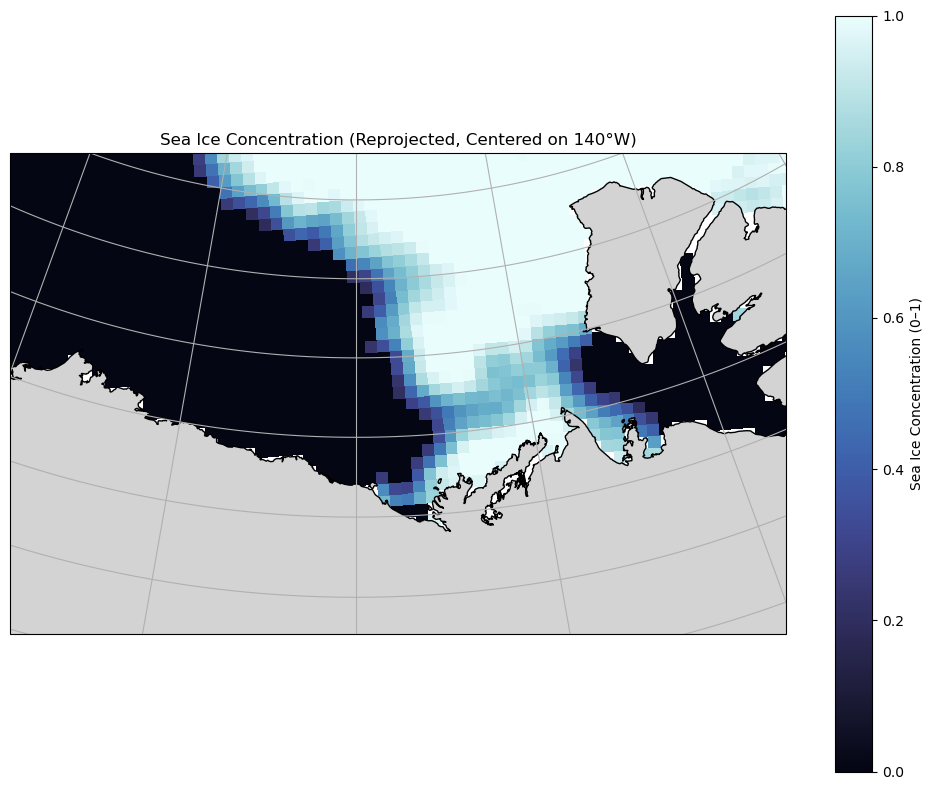

In [50]:
# Extract and normalize sea ice concentration
sic = ds['cdr_seaice_conc'].squeeze()
if sic.max() > 1.5:
    sic = sic / 100.0

# Extract 2D lat/lon from dataset
lat = ds['lat'].values
lon = ds['lon'].values

# Define polar stereographic projection centered at -140°
proj = ccrs.NorthPolarStereo(central_longitude=-140)

# Create figure and axis
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=proj)

# Add map features
# ax.coastlines()
# ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False)

ax.add_feature(cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',           # '10m' = high-res, '50m' and '110m' = lower-res
    facecolor='lightgray'
))
ax.add_feature(cfeature.COASTLINE.with_scale('10m'))

# Plot using PlateCarree() transform from lon/lat
c = ax.pcolormesh(lon, lat, sic, transform=ccrs.PlateCarree(),
                  cmap=cmocean.cm.ice, shading='auto')

# Add colorbar
plt.colorbar(c, ax=ax, orientation='vertical', label='Sea Ice Concentration (0–1)')

# Optional: zoom to Beaufort Sea
ax.set_extent([-156, -120, 66, 75], crs=ccrs.PlateCarree())

plt.title('Sea Ice Concentration (Reprojected, Centered on 140°W)')
plt.tight_layout()
plt.show()

In [5]:
# Set data directory and load all matching NetCDF files
data_dir = "/home/jpluser/efs-mount-point/mzahn/sic_nsidc_cdr"
file_paths = sorted(glob.glob(os.path.join(data_dir, "*.nc")))

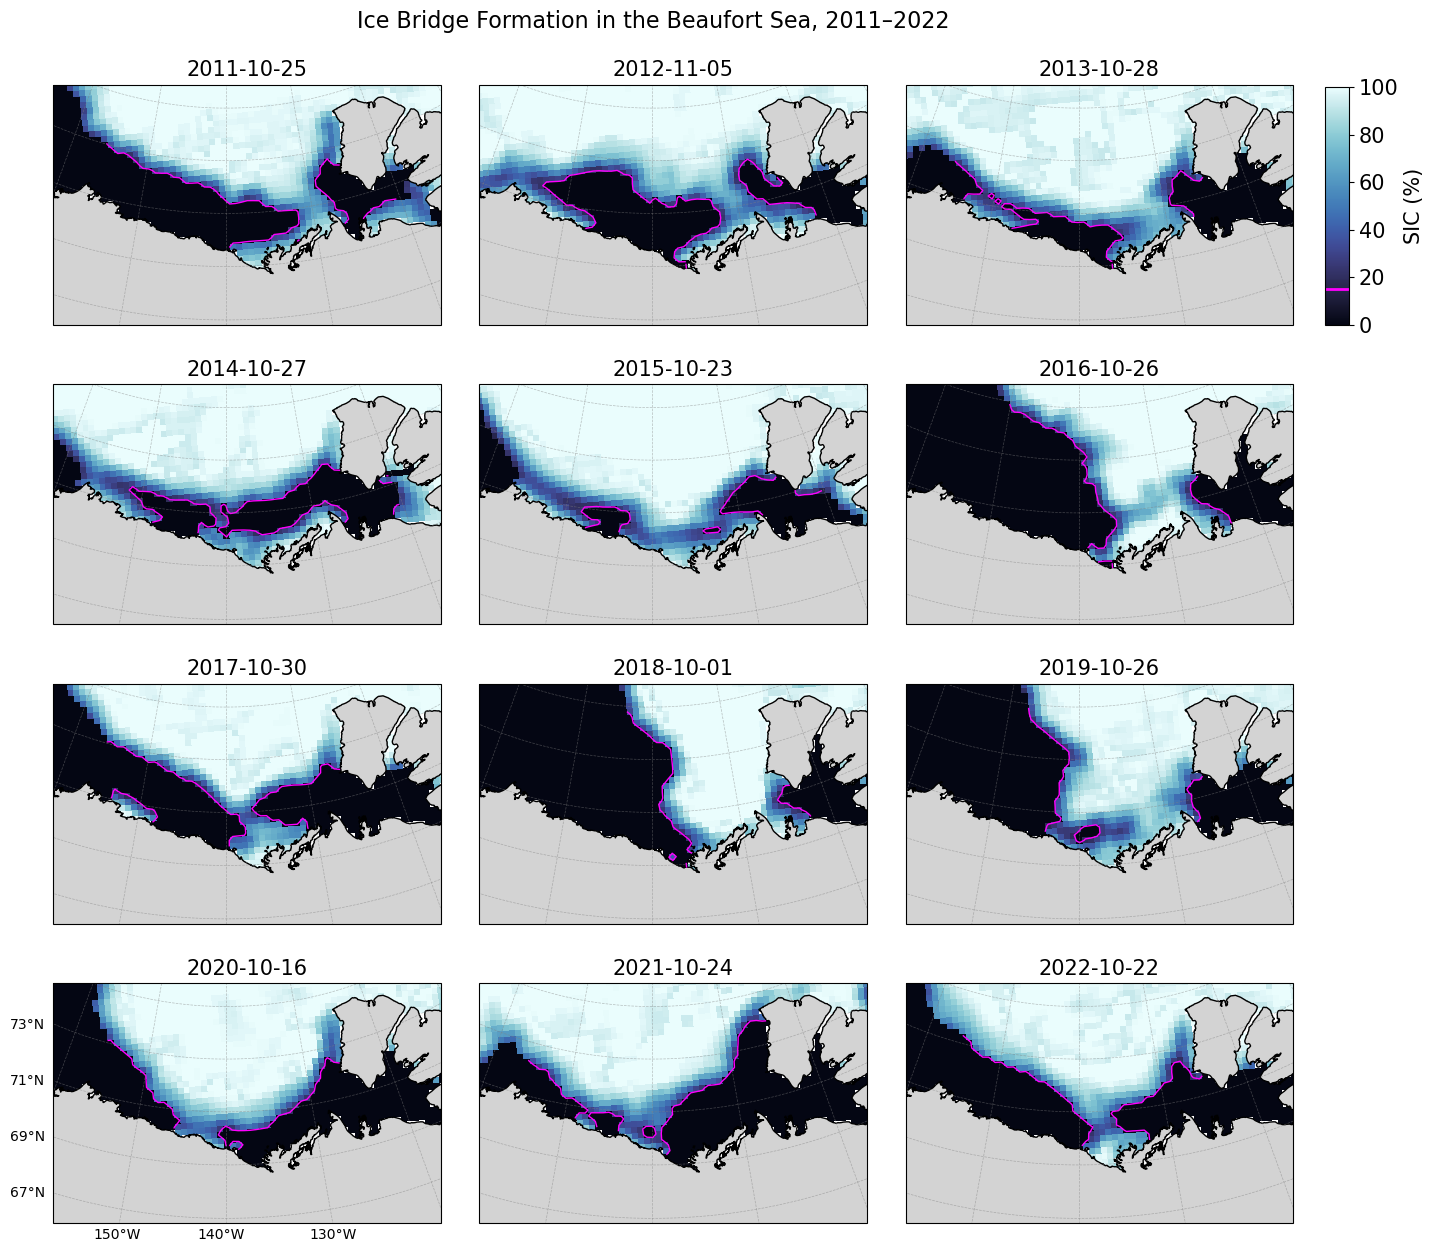

In [ ]:
plt.rcParams['font.size'] = 15

# Define the NSIDC stereographic projection
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# Create multipanel plot (4 rows, 3 columns) with constrained layout
fig, axes = plt.subplots(4, 3, figsize=(16, 14),
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-140)})
plt.subplots_adjust(wspace=0.1, hspace=0.2, right=0.9, top=0.93)
axes = axes.flatten()

# Loop through selected files and plot
pcolormesh_handle = None  # for colorbar
for i, file in enumerate(file_paths):
    ds = xr.open_dataset(file)
    sic = ds['cdr_seaice_conc'].squeeze()
    if sic.max() > 1.5:
        sic = sic / 100.0

    # Get x/y and convert to lat/lon
    x = ds['x'].values
    y = ds['y'].values
    X, Y = np.meshgrid(x, y)
    lon, lat = transformer.transform(X, Y)

    ax = axes[i]
    ax.set_extent([-156, -120, 66, 75], crs=ccrs.PlateCarree())
    # ax.gridlines(draw_labels=False)
    
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--',ylocs=[67, 69, 71, 73, 75])

    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor='lightgray'))
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'))

    # Plot sea ice concentration
    pcolormesh_handle = ax.pcolormesh(lon, lat, sic*100, transform=ccrs.PlateCarree(),
                                      cmap=cmocean.cm.ice, shading='auto')
    # Add 15% contour
    mask = ((lon >= -156) & (lon <= -120) & (lat >= 66) & (lat <= 75))
    sic_masked = np.where(mask, sic, np.nan)
    contour = ax.contour(lon, lat, sic_masked*100,levels=[15],colors='magenta',linewidths=1,transform=ccrs.PlateCarree())

    # Add subplot title
    date_str = np.datetime_as_string(ds['time'].values[0], unit='D')
    ax.set_title(date_str, fontsize=15)

# lat/lon labels
fig.text(0.12, 0.135, '67°N', fontsize=10, ha='right', va='center')  # y-axis label
fig.text(0.12, 0.175, '69°N', fontsize=10, ha='right', va='center')
fig.text(0.12, 0.215, '71°N', fontsize=10, ha='right', va='center')
fig.text(0.12, 0.255, '73°N', fontsize=10, ha='right', va='center')
fig.text(0.165, 0.11, '150°W', fontsize=10, ha='center', va='top')  # x-axis label
fig.text(0.23, 0.11, '140°W', fontsize=10, ha='center', va='top')
fig.text(0.3, 0.11, '130°W', fontsize=10, ha='center', va='top')

# Remove unused axes (should not be necessary here)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a single external colorbar using the last pcolormesh handle
cbar_ax = fig.add_axes([0.92, 0.755, 0.015, 0.17])  # [left, bottom, width, height]
cb = fig.colorbar(pcolormesh_handle, cax=cbar_ax)
cb.set_label('SIC (%)')
cb.ax.hlines(15, *cb.ax.get_xlim(), colors='magenta', linewidth=2)

# Add main title and adjust layout
plt.suptitle("Ice Bridge Formation in the Beaufort Sea, 2011–2022", fontsize=16)
# plt.tight_layout(rect=[0, 0, 0.9, 0.96])  # Leave room for suptitle and colorbar
plt.show()

fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/satellite_bridge_maps.png', \
            dpi=300, bbox_inches='tight')